In [1]:
import sys
from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from langchain_core.messages import HumanMessage,AIMessage,SystemMessage,BaseMessage
from langchain_core.output_parsers import StrOutputParser,PydanticOutputParser
from langchain_core.prompts import PromptTemplate,ChatPromptTemplate,SystemMessagePromptTemplate, HumanMessagePromptTemplate
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph.message import add_messages
sys.path.insert(1, r'C:\Users\Dharmendra Vartika\LLM\env')
from enviorment import load_env
import os 
load_env()
model =ChatOpenAI()
from langgraph.graph import StateGraph,START, END
from typing import TypedDict,Annotated,Literal
import operator
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults
import yfinance as yf
from ta.momentum import RSIIndicator
from pydantic import BaseModel, Field



In [ ]:
search=DuckDuckGoSearchRun()
tool=[search]
llm_with_tools = model.bind_tools(tool)


In [133]:
class model_output(BaseModel):
    """model output"""
    Trend_analysis: str = Field(description="The gives us the trend analysis of the stock")
    Support_Resistance: str = Field(description="The gives us the Support/Resistance levels of stock")
    Technical_rating : Literal["Bullish", "Neutral", "Bearish"]
    Key_signals :str  = Field(description="The gives us key signals stock by looking at the latest news")
    urls :str  = Field(description="The gives us urls for the refrence"),
    sentiments :Literal["positive", "negative", "neutral"]  = Field(description="The gives us sentiments for the refrence")
    Final_recommendation: Literal["Strong Buy", "Buy", "Hold","Sell",'Strong Sell'] = Field(description="The gives us the final recommendation of the stock")
    Confidence_score: int = Field(description="The gives Confidence score ranging from 0 to 10")
    Target_price_range : float =Field(description='Target price range of the stock')
    news: str = Field(description="recents news of the stock")
model_with_structured_output=model.with_structured_output(model_output)

c:\Anaconda\Lib\site-packages\langchain_openai\chat_models\base.py:1913: UserWarning: Cannot use method='json_schema' with model gpt-3.5-turbo since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(
c:\Anaconda\Lib\site-packages\pydantic\json_schema.py:2324: PydanticJsonSchemaWarning: Default value (FieldInfo(annotation=NoneType, required=True, description='The gives us urls for the refrence'),) is not JSON serializable; excluding default from JSON schema [non-serializable-default]
  warnings.warn(message, PydanticJsonSchemaWarning)


In [181]:
class symbol(BaseModel):
    ticker_symbol: str =Field(description='ticker symbol for the stock')
search=DuckDuckGoSearchRun()
tool=[search]
prompt ='can you get ticker symbol only for the Quantum-Si (QSI) stock'
llm_with_tools = model.bind_tools(tool)
llm_bind=llm_with_tools.with_structured_output(symbol)
tool_node = ToolNode(tool)
#result=llm_bind.invoke(prompt)
#result.ticker_symbol

c:\Anaconda\Lib\site-packages\langchain_openai\chat_models\base.py:1913: UserWarning: Cannot use method='json_schema' with model gpt-3.5-turbo since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


In [182]:
class stock_analyzer(TypedDict):
    data  :dict
    prompt :str
    symbol :str
    Trend_analysis:str
    Support_Resistance:str
    Technical_rating:str
    Key_signals :str
    summary: str
    urls: str
    sentiments:str
    Final_recommendation : str
    Confidence_score :int
    Target_price_range : float
    news :str
    

In [ ]:
news=[]
url =[]
parser=StrOutputParser()
#search_Tavily = TavilySearchResults(max_results=2)
def get_stock(state:stock_analyzer):
    """Node for getting the ticker symbol"""
    prompt =state['prompt']
    result =llm_bind.invoke(prompt)
    stock=result.ticker_symbol
    state['symbol']=stock
    return state
import requests
def get_stock_data(state:stock_analyzer):
    """Node for technical analysis for a given symbol"""
    #prompt =state['prompt']
    #result =llm_bind.invoke(prompt)
    stock=state['symbol']
    stock = yf.Ticker(stock)
    for i in stock.news[:5]:
        date=i['content']['pubDate']
        if date.startswith('2025-10'):
            news.append(i['content']['summary'])
            url.append(i['content']['canonicalUrl']['url'])
        else:
            pass

    newss =' '.join(news)
    urls =', '.join(url)
    hist = stock.history(period='1y')

    # Calculate indicators
    sma_20 = hist['Close'].rolling(window=20).mean()
    sma_50 = hist['Close'].rolling(window=50).mean()
    rsi_indicator = RSIIndicator(close=hist['Close'], window=14)
    rsi = rsi_indicator.rsi()
    state['symbol']=stock
    state['data'] = {
    'current_price': hist['Close'].iloc[-1],
    'sma_20': sma_20.iloc[-1],
    'sma_50': sma_50.iloc[-1],
    'rsi': rsi.iloc[-1],
    'volume_trend': hist['Volume'].iloc[-5:].mean() / hist['Volume'].iloc[-20:].mean(),
    'news' :newss,
    'urls' :urls,

    }
    return state

def get_stock_analyser(state:stock_analyzer):

    symbol=state['symbol']
    data=state['data']
    chatprompt2 = ChatPromptTemplate.from_messages([SystemMessagePromptTemplate.from_template("""You are a helpful financial assistant """),
                                                HumanMessagePromptTemplate.from_template("""Based on the following analyses  for {symbol}:
        {data}

        Provide:
        1. Trend analysis
        2. Support/Resistance levels
        3. Technical rating (Bullish/Neutral/Bearish)
        4. Key signals using the news provided
        5. extract the news url from the given data
        6 Sentiments anlaysis based on the recent news and trend analysis     
        7 :Final recommendation (Strong Buy/Buy/Hold/Sell/Strong Sell)                                                                                                                                                               
        8. Confidence_score ranging from 0 to 10
        9 :Target price range for the stock                                                                                 
        """)])
    chatprompt_final=chatprompt2.invoke({'symbol':symbol,'data':data})
    result=model_with_structured_output.invoke(chatprompt_final)
    state['Trend_analysis']=result.Trend_analysis
    state['Support_Resistance']=result.Support_Resistance
    state['Technical_rating']=result.Technical_rating
    state['Key_signals']=result.Key_signals
    state['urls']=result.urls
    state['sentiments']=result.sentiments
    state['Final_recommendation']=result.Final_recommendation
    state['Confidence_score']=result.Confidence_score
    state['Target_price_range']=result.Target_price_range
    state['data']={}
    state['news']=''
    return state
def get_stock_summary(state:stock_analyzer):

    Technical_rating=state['Technical_rating']
    Support_Resistance=state['Support_Resistance']
    Trend_analysis=state['Trend_analysis']
    Key_signals=state['Key_signals']
    symbol =state['symbol']
    news =state['news']
    Final_recommendation=state['Final_recommendation']
    Target_price_range=state['Target_price_range']
    sentiments=state['sentiments']
    chatprompt2 = ChatPromptTemplate.from_messages([SystemMessagePromptTemplate.from_template("""You are a helpful financial assistant """),
                                                
    HumanMessagePromptTemplate.from_template("""Based on the following technical analyses,key signals,support resistence,sentiments, target price
        final recommendation and recents news
         please provide a  brief summary for a
        retail investor which can give him an idea about this stock behaviour, Please mention key points in bold letters
        {Technical_rating},{Trend_analysis}, {Support_Resistance},{Key_signals},{Target_price_range},{sentiments}
         {Final_recommendation} ,{news}                                                                
        """)])
    chatprompt_final=chatprompt2.invoke({'symbol':symbol,'Technical_rating':Technical_rating,'Trend_analysis':Trend_analysis,'Support_Resistance':Support_Resistance,'Key_signals':Key_signals,
                     'Final_recommendation':Final_recommendation,'Target_price_range' :Target_price_range,'sentiments':sentiments,'news':news      })
    result=model.invoke(chatprompt_final)
    state['summary']=result.content
    state['data']={}
    return state



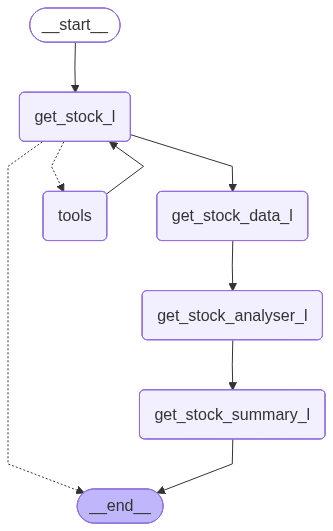

In [205]:
graph=StateGraph(stock_analyzer)
graph.add_node('get_stock_data_l',get_stock_data)
graph.add_node('get_stock_l',get_stock)
graph.add_node('get_stock_analyser_l',get_stock_analyser)
graph.add_node('get_stock_summary_l',get_stock_summary)
graph.add_node('tools',tool_node)
##########################edge nodes############################
graph.add_edge(START,'get_stock_l')
graph.add_edge('get_stock_l','get_stock_data_l')
graph.add_conditional_edges('get_stock_l',tools_condition)
graph.add_edge('tools','get_stock_l')
graph.add_edge('get_stock_data_l','get_stock_analyser_l')
graph.add_edge('get_stock_analyser_l','get_stock_summary_l')
graph.add_edge('get_stock_summary_l',END)
workflow=graph.compile()
workflow

In [209]:
tool_node

tools(tags=None, recurse=True, explode_args=False, func_accepts={'config': ('N/A', <class 'inspect._empty'>), 'store': ('store', None)}, tools_by_name={'duckduckgo_search': DuckDuckGoSearchRun(api_wrapper=DuckDuckGoSearchAPIWrapper(region='wt-wt', safesearch='moderate', time='y', max_results=5, backend='auto', source='text'))}, tool_to_state_args={'duckduckgo_search': {}}, tool_to_store_arg={'duckduckgo_search': None}, handle_tool_errors=True, messages_key='messages')

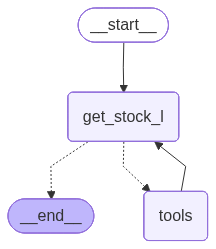

In [ ]:
def get_stock(state:stock_analyzer):
    """Node for getting the ticker symbol"""
    prompt =state['prompt']
    result =llm_bind.invoke(prompt)
    stock=result.ticker_symbol
    state['symbol']=stock
graph=StateGraph(stock_analyzer)
#graph.add_node('get_stock_data_l',get_stock_data)
graph.add_node('get_stock_l',get_stock)
#graph.add_node('get_stock_analyser_l',get_stock_analyser)
#graph.add_node('get_stock_summary_l',get_stock_summary)
graph.add_node('tools',tool_node)
##########################edge nodes############################
graph.add_edge(START,'get_stock_l')
#graph.add_edge('get_stock_l','get_stock_data_l')
graph.add_conditional_edges('get_stock_l',tools_condition)
graph.add_edge('tools','get_stock_l')
#graph.add_edge('get_stock_data_l','get_stock_analyser_l')
#graph.add_edge('get_stock_analyser_l','get_stock_summary_l')
graph.add_edge('get_stock_l',END)
workflow=graph.compile()
workflow

In [208]:
prompt='can you perform technial analysis for the Tesla stock and provide recommendation'
#initial_state={'symbol':symbol}
initial_state={'prompt':prompt}
result=workflow.invoke(initial_state)

ValueError: No messages found in input state to tool_edge: {'prompt': 'can you perform technial analysis for the Tesla stock and provide recommendation'}

In [203]:
result

{'data': {},
 'prompt': 'can you perform technial analysis for the Tesla stock and provide recommendation',
 'symbol': yfinance.Ticker object <TSLA>,
 'Trend_analysis': 'The trend analysis for TSLA indicates a slight bearish trend as the current price is below the 20-day simple moving average (SMA) of $437.40 and close to the 50-day SMA of $395.51. The Relative Strength Index (RSI) is at 49.53, suggesting a neutral sentiment in the short term.',
 'Support_Resistance': 'The support level for TSLA is around $395.51 (50-day SMA) and the resistance level is at $437.40 (20-day SMA).',
 'Technical_rating': 'Neutral',
 'Key_signals': 'Investors are weighing lackluster earnings from Tesla and rising oil prices after Trump hit Russia with sanctions. Tesla stock fell sharply in the premarket after reporting a fall in profits overnight. Morningstar senior equity analyst Seth Goldstein discussed his expectations for Tesla in the autonomous driving space.',
 'summary': '**Key Points:**\n- **Trend A

In [143]:
result['summary']

"Based on the technical analysis and key signals, Quantum-Si (QSI) is currently exhibiting a bullish trend with significant volatility. The share price has shown a strong upward momentum in the short term, with a notable increase of 24% in a single day and 76% over the past month. The support level for QSI is at $2.10, while the resistance level is at $2.30.\n\nRecent news indicates that Quantum-Si has filed plans to potentially raise up to $300 million by selling a mix of securities, which has caused some concerns among investors regarding dilution. This funding move comes after a period of massive volatility, suggesting that the company is seeking financial flexibility for future growth opportunities.\n\nConsidering the current scenario, the sentiment towards Quantum-Si is neutral, with a target price of 2.4. The final recommendation for retail investors is to consider buying the stock, as the company's strategic financing actions and new product introductions could potentially drive

In [144]:
result['Final_recommendation']

'Buy'

In [147]:
prompt ='can you get me latest price of QSI stock and tell me how much it cost me to buy 50 shares of it'
model.invoke(prompt)

AIMessage(content='I apologize for the inconvenience, but as an AI, I do not have real-time data access. I recommend checking a financial news website, stock market app, or contacting your broker for the latest price of QSI stock. Once you have the current price, you can calculate how much it would cost to buy 50 shares by multiplying the price per share by 50.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 75, 'prompt_tokens': 32, 'total_tokens': 107, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-CToTIdADrt2KTNidQ6EDxPrOX4UQT', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--2dc4f7a7-618b-44ea-9d9e-db8ee9858677-0', usage_metadata={'input_tokens': 32, 'output_tokens': 75,

In [ ]:
class symbol(BaseModel):
    ticker_symbol: str =Field(description='ticker symbol for the stock')


c:\Anaconda\Lib\site-packages\langchain_openai\chat_models\base.py:1913: UserWarning: Cannot use method='json_schema' with model gpt-3.5-turbo since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


In [166]:
search=DuckDuckGoSearchRun()
tool=[search]
prompt ='can you get ticker symbol only for the Quantum-Si stock and perform analysis'
llm_with_tools = model.bind_tools(tool)
llm=llm_with_tools.with_structured_output(symbol)
result=llm.invoke(prompt)

c:\Anaconda\Lib\site-packages\langchain_openai\chat_models\base.py:1913: UserWarning: Cannot use method='json_schema' with model gpt-3.5-turbo since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


In [167]:
result.ticker_symbol

'QSI'

In [177]:
stock='QSI'
yf.Ticker(stock)

yfinance.Ticker object <QSI>